# Ordinal vs. Softmax observation model: test MAE & test correlation

In [2]:
import json
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

RESULTS_DIR = "results/observation_model"

def load_runs(obs_model):
    pattern = os.path.join(RESULTS_DIR, f"*_obs_{obs_model}", "run_*", "validation_metrics_run_*.json")
    runs = {}
    for path in glob.glob(pattern):
        with open(path) as f:
            d = json.load(f)
        runs[d["run_id"]] = d["validation_results"]
    return runs

def metrics_at_epoch(runs, epoch):
    out = {}
    for run_id, val_results in runs.items():
        entry = next((v for v in val_results if v["epoch"] == epoch), None)
        if entry is not None:
            out[run_id] = (entry["mean_test_mae"], entry["mean_test_corr"])
    return out

ordinal_runs = load_runs("ordinal")
softmax_runs = load_runs("softmax")

available_epochs = sorted({v["epoch"] for runs in ordinal_runs.values() for v in runs})
print("Available epochs:", available_epochs)

Available epochs: [150, 300, 450, 600, 750, 900, 1050, 1200, 1350, 1500]


In [3]:
EPOCH = 1500  # <-- set this to one of the available epochs printed above

ordinal_metrics = metrics_at_epoch(ordinal_runs, EPOCH)
softmax_metrics = metrics_at_epoch(softmax_runs, EPOCH)

common_runs = sorted(set(ordinal_metrics) & set(softmax_metrics), key=int)
print(f"Paired runs (same run_id/seed) available at epoch {EPOCH}: {common_runs}")

mae_ordinal = np.array([ordinal_metrics[r][0] for r in common_runs])
mae_softmax = np.array([softmax_metrics[r][0] for r in common_runs])
corr_ordinal = np.array([ordinal_metrics[r][1] for r in common_runs])
corr_softmax = np.array([softmax_metrics[r][1] for r in common_runs])
corr_mask = ~(np.isnan(corr_ordinal) | np.isnan(corr_softmax))

mae_t, mae_p = ttest_rel(mae_ordinal, mae_softmax)
corr_t, corr_p = ttest_rel(corr_ordinal[corr_mask], corr_softmax[corr_mask])

print(f"Test MAE:  ordinal={mae_ordinal.mean():.3f}  softmax={mae_softmax.mean():.3f}  "
      f"paired t-test p={mae_p:.4f}  (n={len(common_runs)})")
print(f"Test corr: ordinal={corr_ordinal[corr_mask].mean():.3f}  softmax={corr_softmax[corr_mask].mean():.3f}  "
      f"paired t-test p={corr_p:.4f}  (n={corr_mask.sum()})")

Paired runs (same run_id/seed) available at epoch 1500: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
Test MAE:  ordinal=0.730  softmax=0.754  paired t-test p=0.0767  (n=10)
Test corr: ordinal=0.636  softmax=0.600  paired t-test p=0.0019  (n=10)


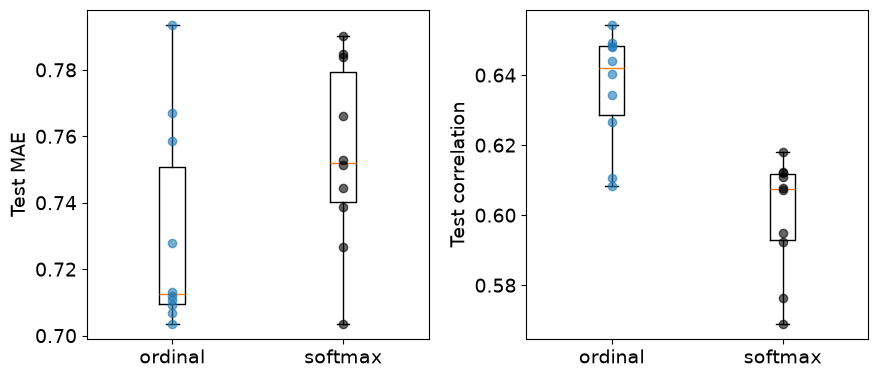

In [11]:
#plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 14
plt.rcParams['lines.linewidth'] = 2.

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (ord_vals, sm_vals, title) in zip(axes, [
    (mae_ordinal, mae_softmax, "Test MAE"),
    (corr_ordinal[corr_mask], corr_softmax[corr_mask], "Test correlation"),
]):
    ax.boxplot([ord_vals, sm_vals])
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["ordinal", "softmax"])
    ax.scatter(np.ones_like(ord_vals), ord_vals, alpha=0.6, zorder=3, label="Ordinal", color="tab:blue")
    ax.scatter(np.full_like(sm_vals, 2), sm_vals, alpha=0.6, zorder=3, label="Softmax", color="black")
    ax.set_ylabel(f"{title}")
    #ax.legend()

plt.tight_layout()
plt.show()

## Error over training (mean ± std across runs)

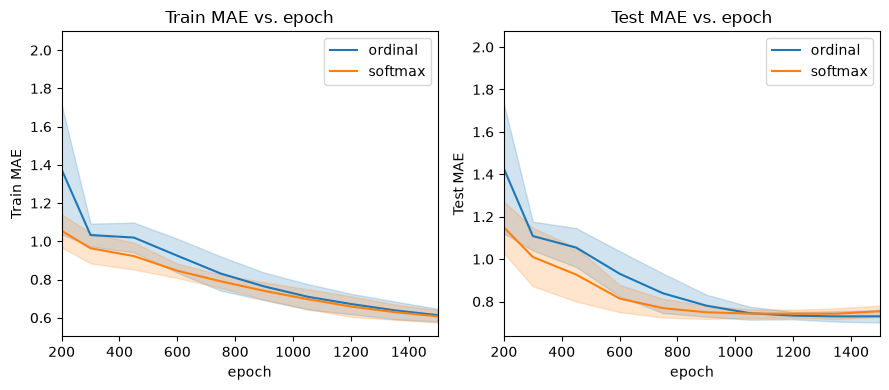

In [18]:
def epoch_trajectory(runs, metric_key):
    by_epoch = {}
    for val_results in runs.values():
        for v in val_results:
            by_epoch.setdefault(v["epoch"], []).append(v[metric_key])
    epochs = np.array(sorted(by_epoch))
    means = np.array([np.nanmean(by_epoch[e]) for e in epochs])
    stds = np.array([np.nanstd(by_epoch[e]) for e in epochs])
    return epochs, means, stds

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, metric_key, title in zip(axes, ["mean_train_mae", "mean_test_mae"], ["Train MAE", "Test MAE"]):
    for runs, label, color in [(ordinal_runs, "ordinal", "tab:blue"), (softmax_runs, "softmax", "tab:orange")]:
        epochs, means, stds = epoch_trajectory(runs, metric_key)
        ax.plot(epochs, means, label=label, color=color)
        ax.fill_between(epochs, means - stds, means + stds, alpha=0.2, color=color)
    ax.set_xlabel("epoch")
    ax.set_ylabel(title)
    ax.set_title(f"{title} vs. epoch")
    ax.set_xlim(200,1500)
    ax.legend()

plt.tight_layout()
plt.show()